<a href="https://colab.research.google.com/github/issaalaje/assignment-2-AI/blob/main/assignemnt_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Example: import pandas as pd
# Add your imports here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [4]:
# --- Data Collection and Loading ---
# TODO: Load the 'Housing' dataset from sklearn and convert it into a pandas DataFrame
df = pd.read_csv('Housing.csv')


In [5]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


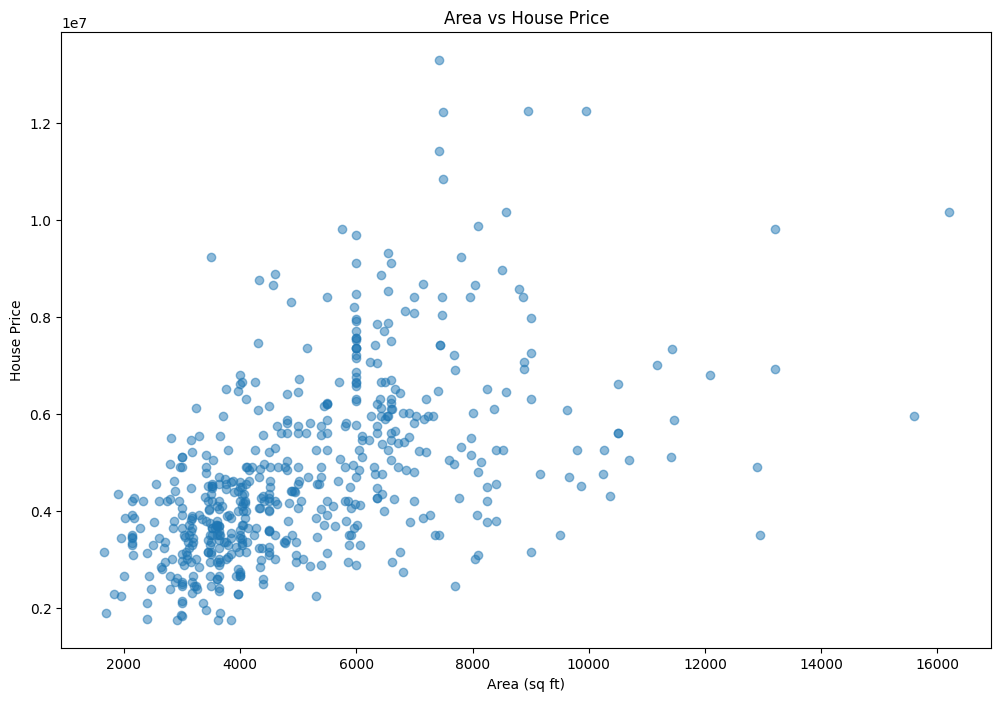

In [8]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable (price).
# Example: Use `plt.scatter()` to visualize the relationship between 'price' and 'area'.
plt.figure(figsize=(12, 8))
plt.scatter(df['area'], df['price'], alpha=0.5)
plt.title('Area vs House Price')
plt.xlabel('Area (sq ft)')
plt.ylabel('House Price')
plt.show()

In [9]:
#TODO: Create a function to automate scatter plots for all features vs MedHouseVal.
# Hint: The function should loop over a list of features and plot scatter plots for each.
num_features = df.select_dtypes(include=np.number).columns.tolist()
def scatter_plots(df, num_features):
  for i in num_features:
    plt.figure(figsize=(12, 8))
    plt.scatter(df[i], df['price'], alpha=0.5)
    plt.title(f'{i} vs House Price')
    plt.xlabel(i)
    plt.ylabel('House Price')
    plt.show()

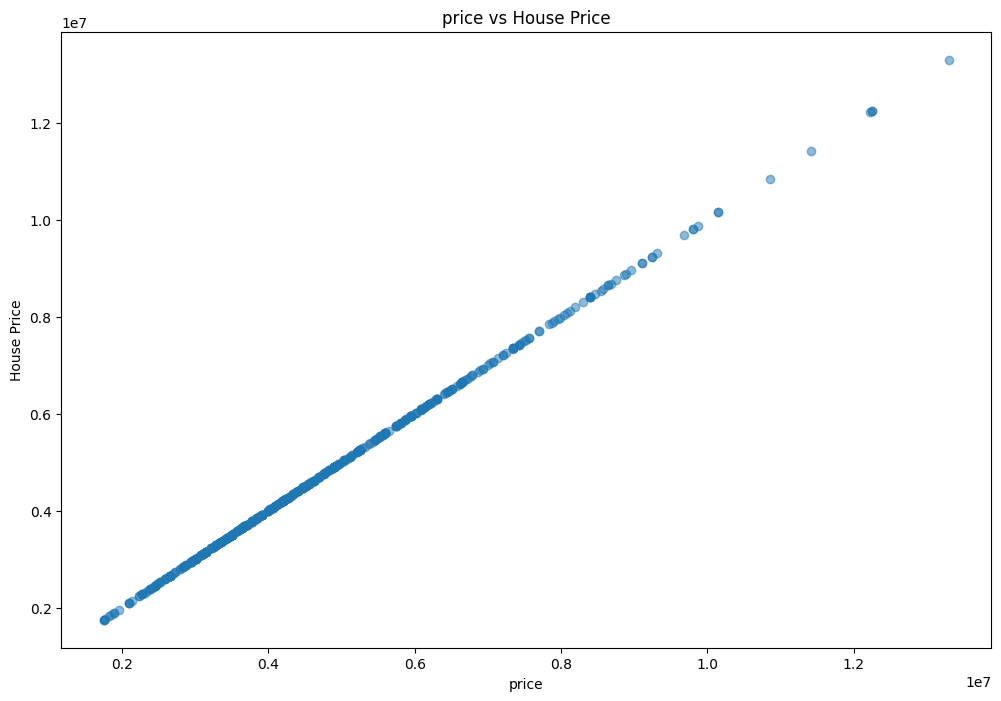

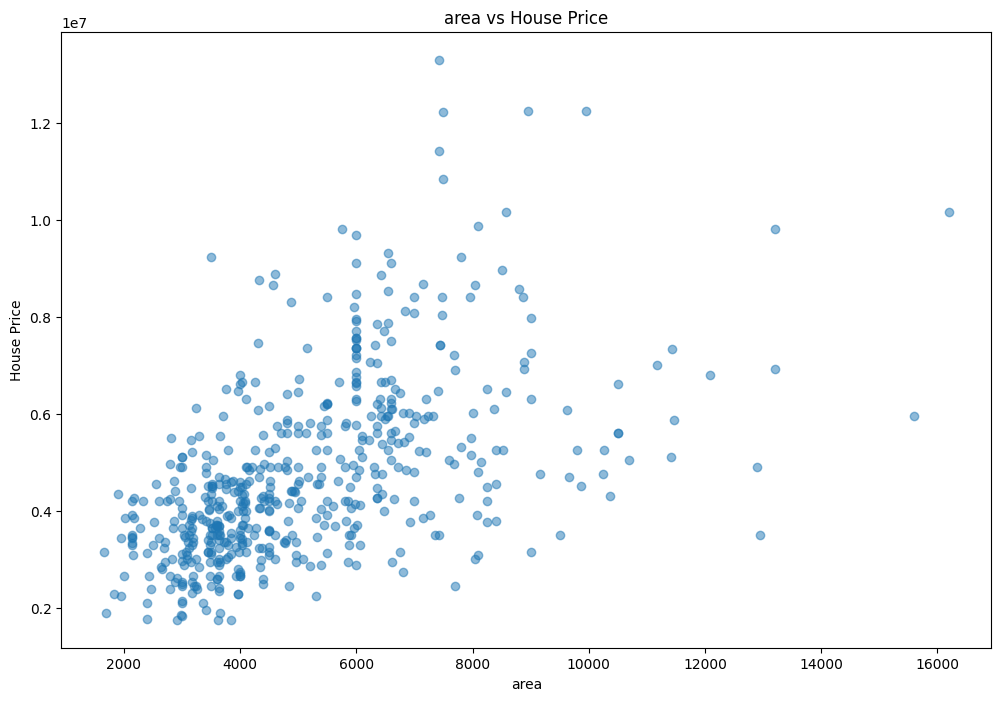

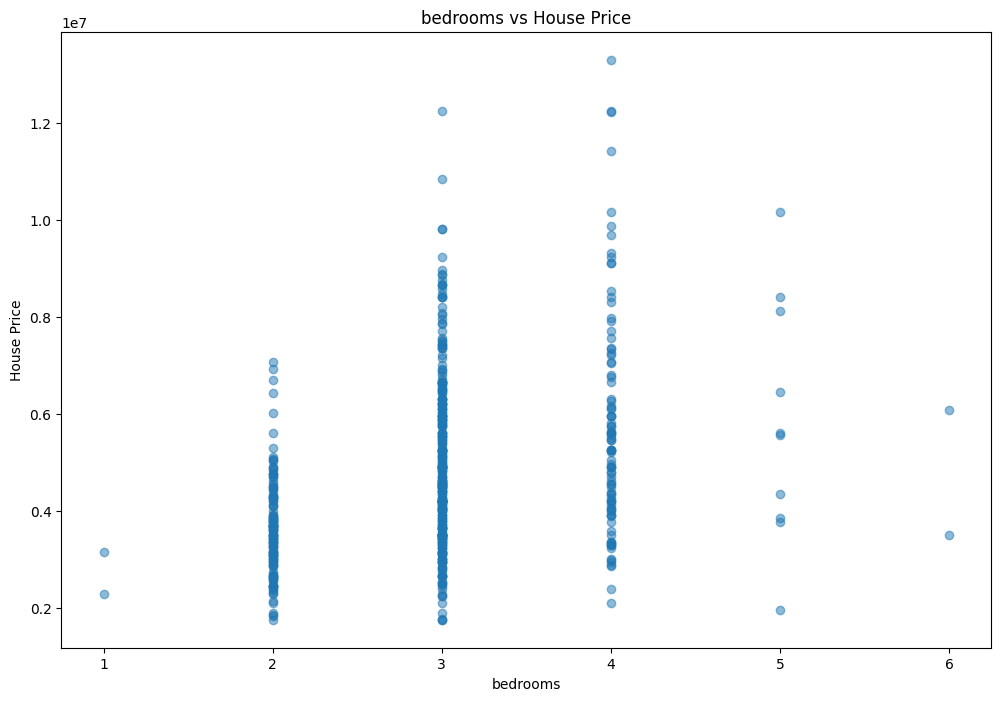

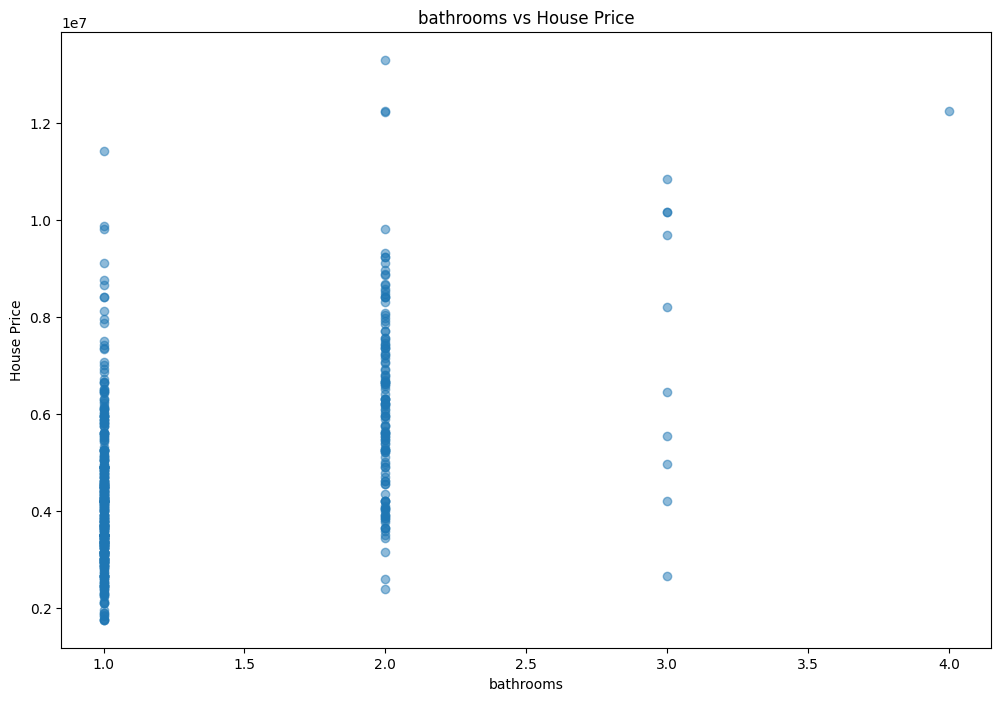

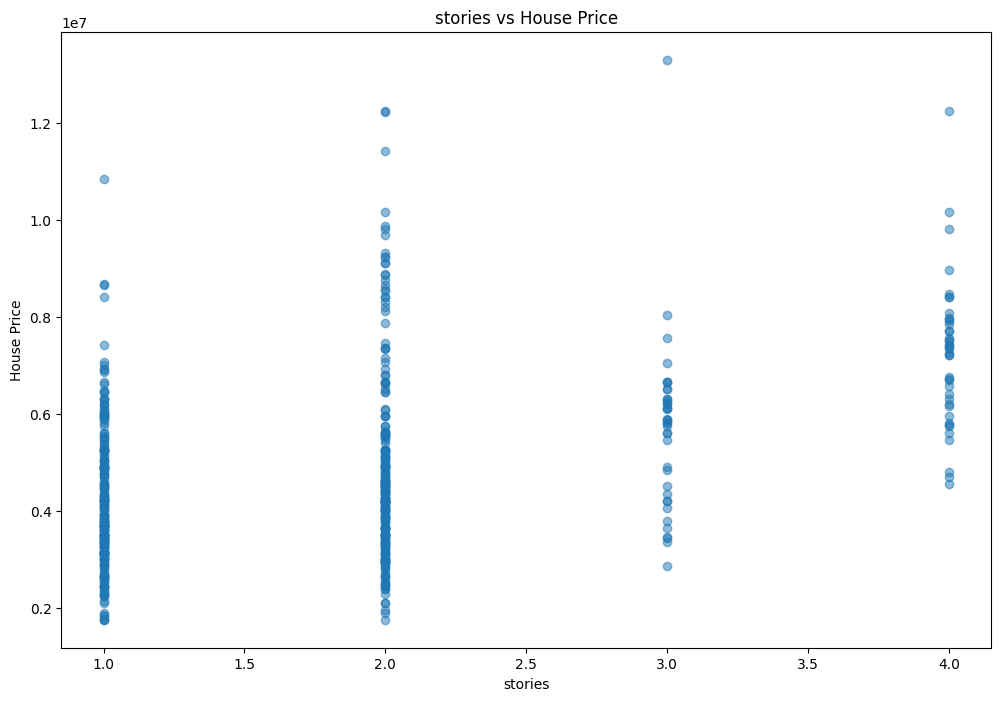

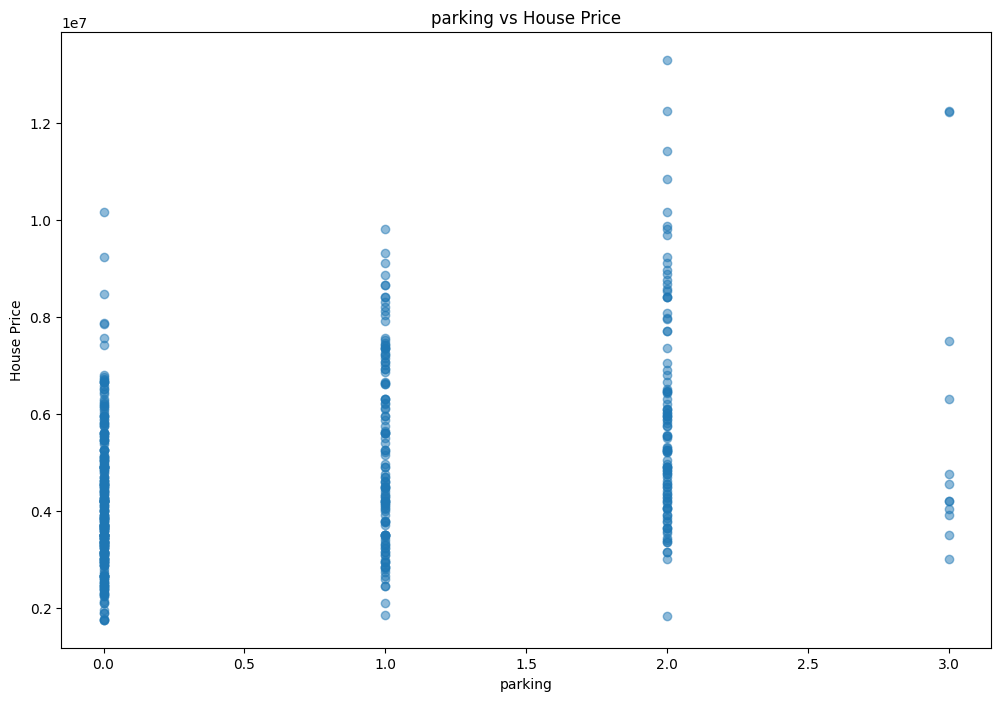

In [10]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.
scatter_plots(df, num_features)

In [16]:
# preparing the data for machine learning
le = LabelEncoder()
object_features = df.select_dtypes(include='object').columns
for i in object_features:
  df[i] = le.fit_transform(df[i])
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [12]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
# TODO: Choose an appropriate regression model.
# Hint: Use `LinearRegression()` from `sklearn.linear_model`.
model = LinearRegression()

In [14]:
# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.6435419628959105


In [15]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Predict on the test set and calculate the evaluation metrics:

Mean Squared Error: 1535047758428.0508
R-squared: 0.6435419628959105


model explains about 64.4% of the variation in your data.
Model is very sensitive to outliers

In [18]:
features = np.array([[8250, 4, 1, 2, 1, 1, 1, 0, 1, 3, 0, 0]])
print(model.predict(features))

[7256913.21834541]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
